<a href="https://colab.research.google.com/github/jinunyachhyon/Vision-Transformer-ViT-/blob/main/Implementing_Vision_Transformer_(ViT)_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import os
import math
import json

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms

# Config

In [2]:
exp_name = 'vit-with-10-epochs' #@param {type:"string"}
batch_size = 32 #@param {type: "integer"}
epochs = 10 #@param {type: "integer"}
lr = 1e-2  #@param {type: "number"}
save_model_every = 0 #@param {type: "integer"}

device = "cuda" if torch.cuda.is_available() else "cpu"

config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": True,
}

# These are not hard constraints, but are used to prevent misconfigurations
assert config["hidden_size"] % config["num_attention_heads"] == 0
assert config['intermediate_size'] == 4 * config['hidden_size']
assert config['image_size'] % config['patch_size'] == 0

# Overview of the ViT Architecture

![Arcitecture](https://tintn.github.io/assets/posts/Implementing-Vision-Transformer-from-Scratch/ViT-arch.png)

The main idea behind ViT is that an image can be seen as a series of patches, which can be treated as tokens in NLP tasks. The input image is split into small patches, which are then flattened into sequences of vectors. These vectors are then processed by a transformer encoder, which allows the model to learn interactions between patches through self-attention mechanism. The output of the transformer encoder is then fed into a classification layer that outputs the predicted class of the input image.

## Transform Images into Embeddings

![Image into Embeddings](https://tintn.github.io/assets/posts/Implementing-Vision-Transformer-from-Scratch/ViT-arch-embed.png)

In order to feed input images to a Transformer model, we need to convert the images to a sequence of vectors. This is done by splitting the image into a grid of non-overlapping patches, which are then linearly projected to obtain a fixed-size embedding vector for each patch.

In [3]:
class PatchEmbeddings(nn.Module):
    """
    Convert the image into patches and then project them into a vector space.
    """

    def __init__(self, config):
        super().__init__()
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.num_channels = config["num_channels"]
        self.hidden_size = config["hidden_size"]
        # Calculate the number of patches from the image size and patch size
        self.num_patches = (self.image_size // self.patch_size) ** 2
        # Create a projection layer to convert the image into patches
        # The layer projects each patch into a vector of size hidden_size
        self.projection = nn.Conv2d(self.num_channels, self.hidden_size, kernel_size=self.patch_size, stride=self.patch_size)

    def forward(self, x):
        # (batch_size, num_channels, image_size, image_size) -> (batch_size, num_patches, hidden_size)
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x

After the patches are converted to a sequence of embeddings, the `[CLS]` token is added to the beginning of the sequence, it will be used later in the classification layer to classify the image. The `[CLS]` token’s embedding is learned during training.

As patches from different positions may contribute differently to the final predictions, we also need a way to encode `patch positions` into the sequence. We’re going to use learnable `position embeddings` to add positional information to the embeddings. This is similar to how position embeddings are used in Transformer models for NLP tasks.

In [4]:
class Embeddings(nn.Module):
    """
    Combine the patch embeddings with the class token and position embeddings.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embeddings = PatchEmbeddings(config)
        # Create a learnable [CLS] token
        # Similar to BERT, the [CLS] token is added to the beginning of the input sequence
        # and is used to classify the entire sequence
        self.cls_token = nn.Parameter(torch.randn(1, 1, config["hidden_size"]))
        # Create position embeddings for the [CLS] token and the patch embeddings
        # Add 1 to the sequence length for the [CLS] token
        self.position_embeddings = \
            nn.Parameter(torch.randn(1, self.patch_embeddings.num_patches + 1, config["hidden_size"]))
        self.dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        x = self.patch_embeddings(x)
        batch_size, _, _ = x.size()
        # Expand the [CLS] token to the batch size
        # (1, 1, hidden_size) -> (batch_size, 1, hidden_size)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # Concatenate the [CLS] token to the beginning of the input sequence
        # This results in a sequence length of (num_patches + 1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embeddings
        x = self.dropout(x)
        return x

At this step, the input image is converted to a sequence of embeddings with positional information and ready to be fed into the transformer layer.

## Multi-head Attention

![MHA](https://tintn.github.io/assets/posts/Implementing-Vision-Transformer-from-Scratch/ViT-arch-attention.png)

The multi-head attention is used to compute the interactions between different patches in the input image. **The multi-head attention consists of multiple attention heads, each of which is a single attention layer.**

Let’s implement a head of the multi-head attention module. The module takes a sequence of embeddings as input and computes `query`, `key`, and `value` vectors for each embedding. The `query` and `key` vectors are then used to compute the attention weights for each token. The attention weights are then used to compute new embeddings using a weighted sum of the `value` vectors.

In [5]:
class AttentionHead(nn.Module):
    """
    A single attention head.
    This module is used in the MultiHeadAttention module.
    """
    def __init__(self, hidden_size, attention_head_size, dropout, bias=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        # Create the query, key, and value projection layers
        self.query = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.key = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.value = nn.Linear(hidden_size, attention_head_size, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Project the input into query, key, and value
        # The same input is used to generate the query, key, and value,
        # so it's usually called self-attention.
        # (batch_size, sequence_length, hidden_size) -> (batch_size, sequence_length, attention_head_size)
        query = self.query(x)
        key = self.key(x)
        value = self.value(x)
        # Calculate the attention scores
        # softmax(Q*K.T/sqrt(head_size))*V
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        attention_probs = nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)
        # Calculate the attention output
        attention_output = torch.matmul(attention_probs, value)
        return (attention_output, attention_probs)

The outputs from all attention heads are then concatenated and linearly projected to obtain the final output of the multi-head attention module.

In [6]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention module.
    This module is used in the TransformerEncoder module.
    """

    def __init__(self, config):
        super().__init__()
        self.hidden_size = config["hidden_size"]
        self.num_attention_heads = config["num_attention_heads"]
        # The attention head size is the hidden size divided by the number of attention heads
        self.attention_head_size = self.hidden_size // self.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        # Whether or not to use bias in the query, key, and value projection layers
        self.qkv_bias = config["qkv_bias"]
        # Create a list of attention heads
        self.heads = nn.ModuleList([])
        for _ in range(self.num_attention_heads):
            head = AttentionHead(
                self.hidden_size,
                self.attention_head_size,
                config["attention_probs_dropout_prob"],
                self.qkv_bias
            )
            self.heads.append(head)
        # Create a linear layer to project the attention output back to the hidden size
        # In most cases, all_head_size and hidden_size are the same
        self.output_projection = nn.Linear(self.all_head_size, self.hidden_size)
        self.output_dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x, output_attentions=False):
        # Calculate the attention output for each attention head
        attention_outputs = [head(x) for head in self.heads]
        # Concatenate the attention outputs from each attention head
        attention_output = torch.cat([attention_output for attention_output, _ in attention_outputs], dim=-1)
        # Project the concatenated attention output back to the hidden size
        attention_output = self.output_projection(attention_output)
        attention_output = self.output_dropout(attention_output)
        # Return the attention output and the attention probabilities (optional)
        if not output_attentions:
            return (attention_output, None)
        else:
            attention_probs = torch.stack([attention_probs for _, attention_probs in attention_outputs], dim=1)
            return (attention_output, attention_probs)

In [7]:
class FasterMultiHeadAttention(nn.Module):
    """
    Multi-head attention module with some optimizations.
    All the heads are processed simultaneously with merged query, key, and value projections.
    """

    def __init__(self, config):
        super().__init__()
        self.hidden_size = config["hidden_size"]
        self.num_attention_heads = config["num_attention_heads"]
        # The attention head size is the hidden size divided by the number of attention heads
        self.attention_head_size = self.hidden_size // self.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        # Whether or not to use bias in the query, key, and value projection layers
        self.qkv_bias = config["qkv_bias"]
        # Create a linear layer to project the query, key, and value
        self.qkv_projection = nn.Linear(self.hidden_size, self.all_head_size * 3, bias=self.qkv_bias)
        self.attn_dropout = nn.Dropout(config["attention_probs_dropout_prob"])
        # Create a linear layer to project the attention output back to the hidden size
        # In most cases, all_head_size and hidden_size are the same
        self.output_projection = nn.Linear(self.all_head_size, self.hidden_size)
        self.output_dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x, output_attentions=False):
        # Project the query, key, and value
        # (batch_size, sequence_length, hidden_size) -> (batch_size, sequence_length, all_head_size * 3)
        qkv = self.qkv_projection(x)
        # Split the projected query, key, and value into query, key, and value
        # (batch_size, sequence_length, all_head_size * 3) -> (batch_size, sequence_length, all_head_size)
        query, key, value = torch.chunk(qkv, 3, dim=-1)
        # Resize the query, key, and value to (batch_size, num_attention_heads, sequence_length, attention_head_size)
        batch_size, sequence_length, _ = query.size()
        query = query.view(batch_size, sequence_length, self.num_attention_heads, self.attention_head_size).transpose(1, 2)
        key = key.view(batch_size, sequence_length, self.num_attention_heads, self.attention_head_size).transpose(1, 2)
        value = value.view(batch_size, sequence_length, self.num_attention_heads, self.attention_head_size).transpose(1, 2)
        # Calculate the attention scores
        # softmax(Q*K.T/sqrt(head_size))*V
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        attention_probs = nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = self.attn_dropout(attention_probs)
        # Calculate the attention output
        attention_output = torch.matmul(attention_probs, value)
        # Resize the attention output
        # from (batch_size, num_attention_heads, sequence_length, attention_head_size)
        # To (batch_size, sequence_length, all_head_size)
        attention_output = attention_output.transpose(1, 2) \
                                           .contiguous() \
                                           .view(batch_size, sequence_length, self.all_head_size)
        # Project the attention output back to the hidden size
        attention_output = self.output_projection(attention_output)
        attention_output = self.output_dropout(attention_output)
        # Return the attention output and the attention probabilities (optional)
        if not output_attentions:
            return (attention_output, None)
        else:
            return (attention_output, attention_probs)

Focusing on how the matrices are manipulated in a Faster multi-head attention layer. We'll use an input tensor $x$ with shape $(1, 65, 144)$, where:

- **Batch size**: 1 (a single input sequence)
- **Sequence length**: 65 (number of tokens in the sequence)
- **Hidden size**: 48 (dimension of each token embedding)

### Configuration
- `num_attention_heads = 4`
- `attention_head_size = hidden_size / num_attention_heads = 48 / 4 = 12`

### Step-by-Step Matrix Operations
1. **Input Projection for Query, Key, and Value:**

   The linear layer `qkv_projection` projects $x$ into a concatenated tensor containing queries, keys, and values:
   - Input: $x$ of shape 1, 65, 48.
   - Output: qkv of shape $(1, 65, 48 \times 3)$ = $(1, 65, 144)$.
   
   Here, 48 (hidden size) is multiplied by 3 to create a single tensor that contains all the query, key, and value vectors.

2. **Splitting into Query, Key, and Value:**

   We split `qkv` into three separate tensors:
   - $\text{query}, \text{key}, \text{value}$: Each of shape (1, 65, 48).
   
3. **Reshaping for Multi-Head Attention:**

   Each of the query, key, and value tensors is reshaped and transposed for the multi-head attention:
   - $\text{query}$ reshaped to (1, 65, 4, 12) and then transposed to (1, 4, 65, 12).
   - $\text{key}$ reshaped to (1, 65, 4, 12) and then transposed to (1, 4, 65, 12).
   - $\text{value}$ reshaped to (1, 65, 4, 12) and then transposed to (1, 4, 65, 12).
   
   Here, the shape (1, 4, 65, 12) represents:
   - **Batch size**: 1.
   - **Number of heads**: 4.
   - **Sequence length**: 65.
   - **Head size**: 12.

4. **Calculating Attention Scores:**

   The attention scores are computed using the dot product of the query and key vectors:
   - $\text{attention_scores} = \text{query} \times \text{key}^T / \sqrt{12}$.
   - Shape of $\text{query}$: (1, 4, 65, 12).
   - Shape of $\text{key}$: (1, 4, 12, 65) (transposed).
   - Resulting shape of $\text{attention_scores}$: (1, 4, 65, 65).

   This results in a score matrix for each head that measures the similarity between each token in the sequence with every other token.

5. **Softmax and Dropout on Attention Scores:**

   Apply softmax to get the attention probabilities and use dropout for regularization:
   - Shape of $\text{attention_probs}$: (1, 4, 65, 65).

6. **Calculating Attention Output:**

   The attention output is obtained by applying the attention probabilities to the value tensor:
   - $\text{attention_output} = \text{attention_probs} \times \text{value}$.
   - Shape of $\text{value}$: (1, 4, 65, 12).
   - Resulting shape of $\text{attention_output}$: (1, 4, 65, 12).

7. **Combining Heads:**

   Concatenate the attention output across all heads:
   - Reshape $\text{attention_output}$ to (1, 65, 48).

8. **Final Output Projection:**

   Project the concatenated output back to the original hidden size using the `output_projection` layer:
   - Final shape of output: (1, 65, 48).

The `FasterMultiHeadAttention` module processes the query, key, and value projections simultaneously in a single step, which reduces computational overhead and speeds up attention calculations by avoiding separate projections for each. This makes the overall attention mechanism more efficient.

## Transformer Encoder

![Transformer Encoder](https://tintn.github.io/assets/posts/Implementing-Vision-Transformer-from-Scratch/ViT-arch-encoder.png)

The transformer encoder is made of a stack of transformer layers. Each transformer layer mainly consists of a multi-head attention module that we just implemented and a feed-forward network. To better scale the model and stabilize training, two Layer normalization layers and skip connections are added to the transformer layer.

In [8]:
class NewGELUActivation(nn.Module):
    """
    Implementation of the GELU activation function currently in Google BERT repo (identical to OpenAI GPT). Also see
    the Gaussian Error Linear Units paper: https://arxiv.org/abs/1606.08415

    Taken from https://github.com/huggingface/transformers/blob/main/src/transformers/activations.py
    """

    def forward(self, input):
        return 0.5 * input * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (input + 0.044715 * torch.pow(input, 3.0))))

In [9]:
class MLP(nn.Module):
    """
    A multi-layer perceptron module.
    """

    def __init__(self, config):
        super().__init__()
        self.dense_1 = nn.Linear(config["hidden_size"], config["intermediate_size"])
        self.activation = NewGELUActivation()
        self.dense_2 = nn.Linear(config["intermediate_size"], config["hidden_size"])
        self.dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        x = self.dense_1(x)
        x = self.activation(x)
        x = self.dense_2(x)
        x = self.dropout(x)
        return x

We have implemented the multi-head attention and the MLP, we can combine them to create the transformer layer. The skip connections and layer normalization are applied to the input of each layer

In [10]:
class Block(nn.Module):
    """
    A single transformer block.
    """

    def __init__(self, config):
        super().__init__()
        self.use_faster_attention = config.get("use_faster_attention", False)
        if self.use_faster_attention:
            self.attention = FasterMultiHeadAttention(config)
        else:
            self.attention = MultiHeadAttention(config)
        self.layernorm_1 = nn.LayerNorm(config["hidden_size"])
        self.mlp = MLP(config)
        self.layernorm_2 = nn.LayerNorm(config["hidden_size"])

    def forward(self, x, output_attentions=False):
        # Self-attention
        attention_output, attention_probs = \
            self.attention(self.layernorm_1(x), output_attentions=output_attentions)
        # Skip connection
        x = x + attention_output
        # Feed-forward network
        mlp_output = self.mlp(self.layernorm_2(x))
        # Skip connection
        x = x + mlp_output
        # Return the transformer block's output and the attention probabilities (optional)
        if not output_attentions:
            return (x, None)
        else:
            return (x, attention_probs)

The transformer encoder stacks multiple transformer layers sequentially:

In [11]:
class Encoder(nn.Module):
    """
    The transformer encoder module.
    """

    def __init__(self, config):
        super().__init__()
        # Create a list of transformer blocks
        self.blocks = nn.ModuleList([])
        for _ in range(config["num_hidden_layers"]):
            block = Block(config)
            self.blocks.append(block)

    def forward(self, x, output_attentions=False):
        # Calculate the transformer block's output for each block
        all_attentions = []
        for block in self.blocks:
            x, attention_probs = block(x, output_attentions=output_attentions)
            if output_attentions:
                all_attentions.append(attention_probs)
        # Return the encoder's output and the attention probabilities (optional)
        if not output_attentions:
            return (x, None)
        else:
            return (x, all_attentions)

## ViT for image classification

After inputting the image to the embedding layer and transformer encoder, we obtain new embeddings for both the image patches and the `[CLS]` token. At this point, the embeddings should have some useful signals for classification after being processed by the transformer encoder. Similar to BERT, we’ll use only the `[CLS]` token’s embedding to pass to the classification layer.

The classification layer is a fully connected layer that takes the `[CLS]` embedding as input and outputs logits for each image. The following code implements the ViT model for image classification:

In [12]:
class ViTForClassfication(nn.Module):
    """
    The ViT model for classification.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.image_size = config["image_size"]
        self.hidden_size = config["hidden_size"]
        self.num_classes = config["num_classes"]
        # Create the embedding module
        self.embedding = Embeddings(config)
        # Create the transformer encoder module
        self.encoder = Encoder(config)
        # Create a linear layer to project the encoder's output to the number of classes
        self.classifier = nn.Linear(self.hidden_size, self.num_classes)
        # Initialize the weights
        self.apply(self._init_weights)

    def forward(self, x, output_attentions=False):
        # Calculate the embedding output
        embedding_output = self.embedding(x)
        # Calculate the encoder's output
        encoder_output, all_attentions = self.encoder(embedding_output, output_attentions=output_attentions)
        # Calculate the logits, take the [CLS] token's output as features for classification
        logits = self.classifier(encoder_output[:, 0, :])
        # Return the logits and the attention probabilities (optional)
        if not output_attentions:
            return (logits, None)
        else:
            return (logits, all_attentions)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=self.config["initializer_range"])
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
        elif isinstance(module, Embeddings):
            module.position_embeddings.data = nn.init.trunc_normal_(
                module.position_embeddings.data.to(torch.float32),
                mean=0.0,
                std=self.config["initializer_range"],
            ).to(module.position_embeddings.dtype)

            module.cls_token.data = nn.init.trunc_normal_(
                module.cls_token.data.to(torch.float32),
                mean=0.0,
                std=self.config["initializer_range"],
            ).to(module.cls_token.dtype)

# Prepare Data

In [13]:
def prepare_data(batch_size=4, num_workers=2, train_sample_size=None, test_sample_size=None):
    train_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=2),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=train_transform)
    if train_sample_size is not None:
        # Randomly sample a subset of the training set
        indices = torch.randperm(len(trainset))[:train_sample_size]
        trainset = torch.utils.data.Subset(trainset, indices)



    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                            shuffle=True, num_workers=num_workers)

    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=test_transform)
    if test_sample_size is not None:
        # Randomly sample a subset of the test set
        indices = torch.randperm(len(testset))[:test_sample_size]
        testset = torch.utils.data.Subset(testset, indices)

    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                            shuffle=False, num_workers=num_workers)

    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    return trainloader, testloader, classes

# Utils

In [14]:
def save_checkpoint(experiment_name, model, epoch, base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)
    os.makedirs(outdir, exist_ok=True)
    cpfile = os.path.join(outdir, f'model_{epoch}.pt')
    torch.save(model.state_dict(), cpfile)

In [15]:
def save_experiment(experiment_name, config, model, train_losses, test_losses, accuracies, base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)
    os.makedirs(outdir, exist_ok=True)

    # Save the config
    configfile = os.path.join(outdir, 'config.json')
    with open(configfile, 'w') as f:
        json.dump(config, f, sort_keys=True, indent=4)

    # Save the metrics
    jsonfile = os.path.join(outdir, 'metrics.json')
    with open(jsonfile, 'w') as f:
        data = {
            'train_losses': train_losses,
            'test_losses': test_losses,
            'accuracies': accuracies,
        }
        json.dump(data, f, sort_keys=True, indent=4)

    # Save the model
    save_checkpoint(experiment_name, model, "final", base_dir=base_dir)

In [16]:
def load_experiment(experiment_name, checkpoint_name="model_final.pt", base_dir="experiments"):
    outdir = os.path.join(base_dir, experiment_name)

    # Load the config
    configfile = os.path.join(outdir, 'config.json')
    with open(configfile, 'r') as f:
        config = json.load(f)

    # Load the metrics
    jsonfile = os.path.join(outdir, 'metrics.json')
    with open(jsonfile, 'r') as f:
        data = json.load(f)
    train_losses = data['train_losses']
    test_losses = data['test_losses']
    accuracies = data['accuracies']

    # Load the model
    model = ViTForClassfication(config)
    cpfile = os.path.join(outdir, checkpoint_name)
    model.load_state_dict(torch.load(cpfile))
    return config, model, train_losses, test_losses, accuracies

In [17]:
def visualize_images():
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True)
    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    # Pick 30 samples randomly
    indices = torch.randperm(len(trainset))[:30]
    images = [np.asarray(trainset[i][0]) for i in indices]
    labels = [trainset[i][1] for i in indices]
    # Visualize the images using matplotlib
    fig = plt.figure(figsize=(10, 10))
    for i in range(30):
        ax = fig.add_subplot(6, 5, i+1, xticks=[], yticks=[])
        ax.imshow(images[i])
        ax.set_title(classes[labels[i]])

In [18]:
@torch.no_grad()
def visualize_attention(model, output=None, device="cuda"):
    """
    Visualize the attention maps of the first 4 images.
    """
    model.eval()
    # Load random images
    num_images = 30
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    # Pick 30 samples randomly
    indices = torch.randperm(len(testset))[:num_images]
    raw_images = [np.asarray(testset[i][0]) for i in indices]
    labels = [testset[i][1] for i in indices]
    # Convert the images to tensors
    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    images = torch.stack([test_transform(image) for image in raw_images])
    # Move the images to the device
    images = images.to(device)
    model = model.to(device)
    # Get the attention maps from the last block
    logits, attention_maps = model(images, output_attentions=True)
    # Get the predictions
    predictions = torch.argmax(logits, dim=1)
    # Concatenate the attention maps from all blocks
    attention_maps = torch.cat(attention_maps, dim=1)
    # select only the attention maps of the CLS token
    attention_maps = attention_maps[:, :, 0, 1:]
    # Then average the attention maps of the CLS token over all the heads
    attention_maps = attention_maps.mean(dim=1)
    # Reshape the attention maps to a square
    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size)
    # Resize the map to the size of the image
    attention_maps = attention_maps.unsqueeze(1)
    attention_maps = F.interpolate(attention_maps, size=(32, 32), mode='bilinear', align_corners=False)
    attention_maps = attention_maps.squeeze(1)
    # Plot the images and the attention maps
    fig = plt.figure(figsize=(20, 10))
    mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))], axis=1)
    for i in range(num_images):
        ax = fig.add_subplot(6, 5, i+1, xticks=[], yticks=[])
        img = np.concatenate((raw_images[i], raw_images[i]), axis=1)
        ax.imshow(img)
        # Mask out the attention map of the left image
        extended_attention_map = np.concatenate((np.zeros((32, 32)), attention_maps[i].cpu()), axis=1)
        extended_attention_map = np.ma.masked_where(mask==1, extended_attention_map)
        ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
        # Show the ground truth and the prediction
        gt = classes[labels[i]]
        pred = classes[predictions[i]]
        ax.set_title(f"gt: {gt} / pred: {pred}", color=("green" if gt==pred else "red"))
    if output is not None:
        plt.savefig(output)
    plt.show()

Let's break down the sizes of `logits` and `attention_maps` produced by the line `logits, attention_maps = model(images, output_attentions=True)` and then go through the subsequent processing steps in detail.

### 1. Understanding `logits` and `attention_maps`:
- **`images`**:
  - Size: `(batch_size, 3, 32, 32)`
  - In this function, `batch_size` is `30` (since `num_images = 30`), `3` represents the RGB channels, and `32x32` is the image resolution.

- **`model(images, output_attentions=True)`**:
  - This method is calling the model's forward function, which processes the images and returns two outputs:
    1. **`logits`**: The output class scores.
    2. **`attention_maps`**: The attention weights from the model's self-attention layers (because `output_attentions=True`).

#### `logits`:
- **Size**: `(batch_size, num_classes)`
  - Here, `batch_size` is `30`, and `num_classes` is `10` (because CIFAR-10 has 10 classes).
  - Example: `(30, 10)`

  This tensor contains the scores for each of the `10` classes for each image in the batch. During prediction, these scores will be converted into class predictions using `torch.argmax`.

#### `attention_maps`:
- **Size**: A list of tensors with attention maps from each transformer layer.
  - Suppose the model has `L` transformer layers and `H` attention heads in each layer, and it outputs `output_attentions=True`.
  - Each element in `attention_maps` has the size: `(batch_size, H, num_patches + 1, num_patches + 1)`.
    - `num_patches + 1`: The `+1` accounts for the CLS token, which is typically used in transformer-based models for classification.
    - `num_patches`: If the image is split into patches, the number of patches would be `(32/patch_size) * (32/patch_size)` (assuming square patches). For instance, if `patch_size = 8`, there would be `16` patches along each dimension, resulting in `num_patches = 16 * 16 = 256`.
    - Example: Suppose `num_patches = 256` and `H = 8`. The attention map from a single layer would have the shape: `(30, 8, 257, 257)`.
  - `attention_maps` is thus a list with `L` tensors of this shape, one for each layer.

### 2. Processing `attention_maps`:
After obtaining `attention_maps`, we process them with the following steps:

#### a. **Concatenating Attention Maps**:
```python
attention_maps = torch.cat(attention_maps, dim=1)
```
- This concatenates the attention maps from all `L` layers along the head dimension.
- **New Size**: `(batch_size, L * H, num_patches + 1, num_patches + 1)`.
  - For example, if there are `12` layers (`L = 12`) and `8` heads per layer (`H = 8`), the size would be `(30, 96, 257, 257)` (since `L * H = 12 * 8 = 96`).

#### b. **Select Attention Maps of the CLS Token**:
```python
attention_maps = attention_maps[:, :, 0, 1:]
```
- **Purpose**: Focuses on the attention maps related to the CLS token.
- The `0` index corresponds to the CLS token's attention across all heads.
- `1:` selects the remaining tokens (ignoring the CLS token itself).
- **New Size**: `(batch_size, L * H, num_patches)`.
  - Example: `(30, 96, 256)`

#### c. **Average Across Heads**:
```python
attention_maps = attention_maps.mean(dim=1)
```
- **Purpose**: Takes the mean of the attention maps over all the heads to simplify visualization.
- Reduces the number of dimensions from `L * H` heads to a single averaged attention map.
- **New Size**: `(batch_size, num_patches)`.
  - Example: `(30, 256)`

### 3. Reshaping the Attention Maps:
```python
size = int(math.sqrt(num_patches))
attention_maps = attention_maps.view(-1, size, size)
```
- **Purpose**: Reshapes the attention maps from a 1D vector (flattened) back into a 2D square format.
- `size = int(math.sqrt(num_patches))` calculates the side length of the square map.
- **New Size**: `(batch_size, size, size)`.
  - Example: If `num_patches = 256`, then `size = 16` and the shape becomes `(30, 16, 16)`.

#### d. **Upsample to Image Size**:
```python
attention_maps = attention_maps.unsqueeze(1)
attention_maps = F.interpolate(attention_maps, size=(32, 32), mode='bilinear', align_corners=False)
attention_maps = attention_maps.squeeze(1)
```
- **Purpose**: Resizes the attention maps to match the original image size of `32x32` pixels.
- Adds a channel dimension using `unsqueeze(1)` to make the size suitable for interpolation.
- Uses `F.interpolate` with `mode='bilinear'` to smoothly upsample the attention maps.
- **New Size**: `(batch_size, 32, 32)`.
  - Example: `(30, 32, 32)`

### Summary of Key Sizes and Processing:
1. **Initial Sizes**:
   - `logits`: `(30, 10)` (scores for each class)
   - `attention_maps`: List of `L` tensors, each with size `(30, H, 257, 257)`.
2. **Processed Sizes**:
   - After concatenation: `(30, 96, 257, 257)` (for `L = 12`, `H = 8`).
   - After selecting CLS token and averaging: `(30, 256)`.
   - After reshaping: `(30, 16, 16)`.
   - After upsampling: `(30, 32, 32)`.

These processed attention maps are then visualized as overlays on the input images, providing insights into which regions of the image the model focuses on for its predictions.

# Train ViT

In [19]:
class Trainer:
    """
    The simple trainer.
    """

    def __init__(self, model, optimizer, loss_fn, exp_name, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.exp_name = exp_name
        self.device = device

    def train(self, trainloader, testloader, epochs, save_model_every_n_epochs=0):
        """
        Train the model for the specified number of epochs.
        """
        # Keep track of the losses and accuracies
        train_losses, test_losses, accuracies = [], [], []
        # Train the model
        for i in range(epochs):
            train_loss = self.train_epoch(trainloader)
            accuracy, test_loss = self.evaluate(testloader)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
            accuracies.append(accuracy)
            print(f"Epoch: {i+1}, Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Accuracy: {accuracy:.4f}")
            if save_model_every_n_epochs > 0 and (i+1) % save_model_every_n_epochs == 0 and i+1 != epochs:
                print('\tSave checkpoint at epoch', i+1)
                save_checkpoint(self.exp_name, self.model, i+1)
        # Save the experiment
        save_experiment(self.exp_name, config, self.model, train_losses, test_losses, accuracies)

    def train_epoch(self, trainloader):
        """
        Train the model for one epoch.
        """
        self.model.train()
        total_loss = 0
        for batch in trainloader:
            # Move the batch to the device
            batch = [t.to(self.device) for t in batch]
            images, labels = batch
            # Zero the gradients
            self.optimizer.zero_grad()
            # Calculate the loss
            loss = self.loss_fn(self.model(images)[0], labels)
            # Backpropagate the loss
            loss.backward()
            # Update the model's parameters
            self.optimizer.step()
            total_loss += loss.item() * len(images)
        return total_loss / len(trainloader.dataset)

    @torch.no_grad()
    def evaluate(self, testloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in testloader:
                # Move the batch to the device
                batch = [t.to(self.device) for t in batch]
                images, labels = batch

                # Get predictions
                logits, _ = self.model(images)

                # Calculate the loss
                loss = self.loss_fn(logits, labels)
                total_loss += loss.item() * len(images)

                # Calculate the accuracy
                predictions = torch.argmax(logits, dim=1)
                correct += torch.sum(predictions == labels).item()
        accuracy = correct / len(testloader.dataset)
        avg_loss = total_loss / len(testloader.dataset)
        return accuracy, avg_loss

# Main

In [20]:
def main():
    # Training parameters
    save_model_every_n_epochs = save_model_every
    # Load the CIFAR10 dataset
    trainloader, testloader, _ = prepare_data(batch_size=batch_size)
    # Create the model, optimizer, loss function and trainer
    model = ViTForClassfication(config)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    loss_fn = nn.CrossEntropyLoss()
    trainer = Trainer(model, optimizer, loss_fn, exp_name, device=device)
    trainer.train(trainloader, testloader, epochs, save_model_every_n_epochs=save_model_every_n_epochs)


if __name__ == '__main__':
    main()

100%|██████████| 170498071/170498071 [00:05<00:00, 32704432.27it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Epoch: 1, Train loss: 1.8227, Test loss: 1.5746, Accuracy: 0.4293
Epoch: 2, Train loss: 1.5337, Test loss: 1.4367, Accuracy: 0.4741
Epoch: 3, Train loss: 1.4448, Test loss: 1.3816, Accuracy: 0.4860
Epoch: 4, Train loss: 1.3946, Test loss: 1.3332, Accuracy: 0.5178
Epoch: 5, Train loss: 1.3419, Test loss: 1.3714, Accuracy: 0.4983
Epoch: 6, Train loss: 1.3217, Test loss: 1.2993, Accuracy: 0.5326
Epoch: 7, Train loss: 1.3101, Test loss: 1.2615, Accuracy: 0.5527
Epoch: 8, Train loss: 1.2862, Test loss: 1.2398, Accuracy: 0.5478
Epoch: 9, Train loss: 1.2789, Test loss: 1.2416, Accuracy: 0.5472
Epoch: 10, Train loss: 1.2564, Test loss: 1.2054, Accuracy: 0.5635


# Visalize Dataset

Files already downloaded and verified


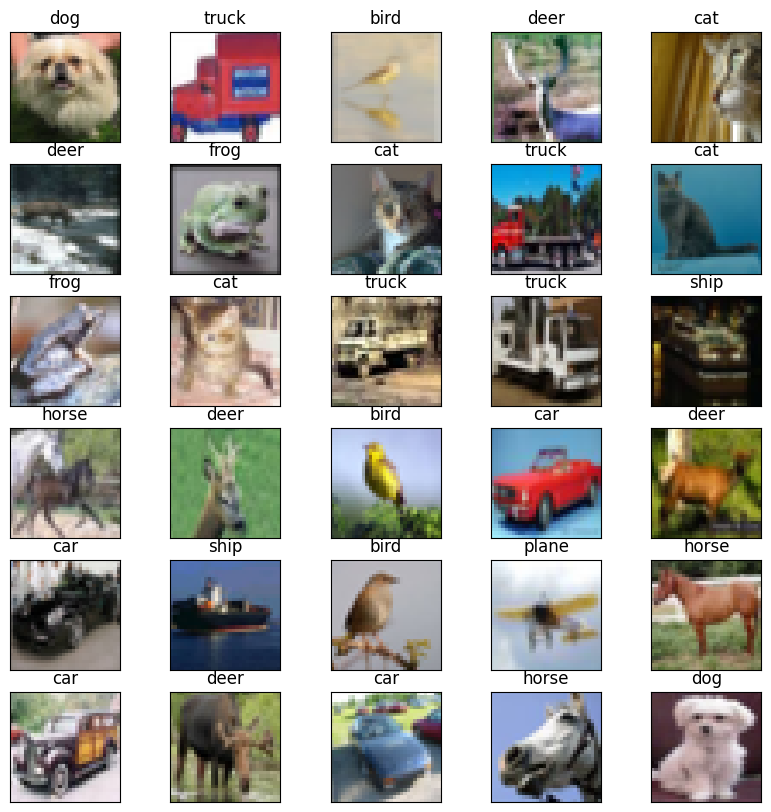

In [21]:
# Show some training images
visualize_images()

# Plot training Results

<ipython-input-16-28c1dadc0cc0>:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(cpfile))


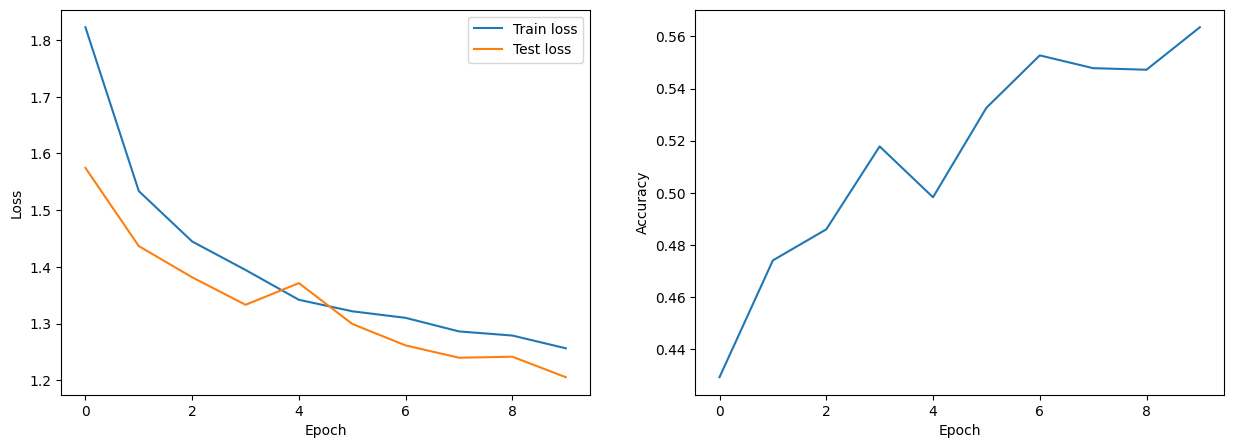

In [22]:
config, model, train_losses, test_losses, accuracies = load_experiment(f"/content/experiments/{exp_name}/")

import matplotlib.pyplot as plt
# Create two subplots of train/test losses and accuracies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(train_losses, label="Train loss")
ax1.plot(test_losses, label="Test loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax2.plot(accuracies)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
plt.savefig("metrics.png")
plt.show()

# Visualize Attention


Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


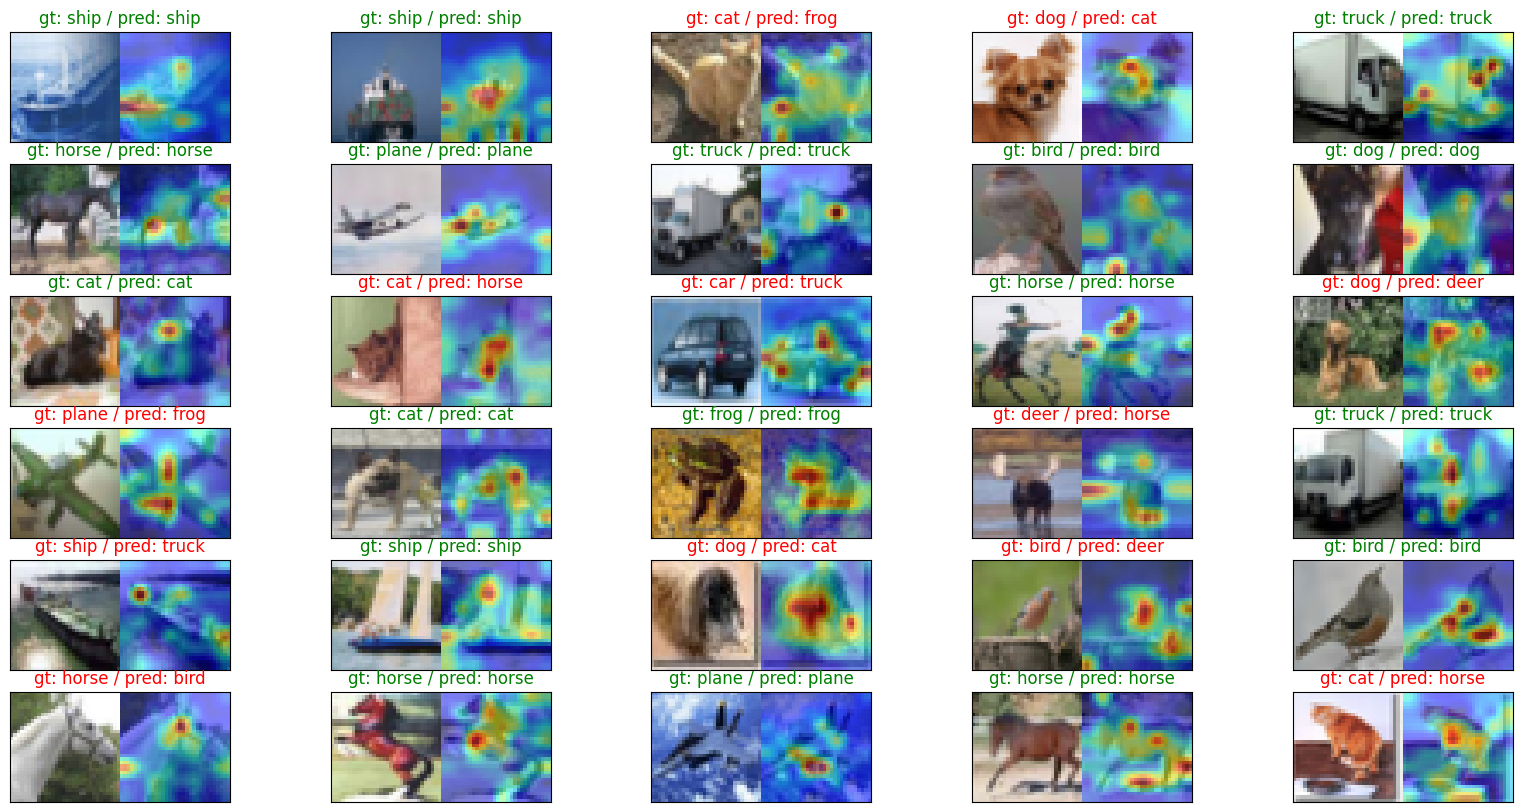

In [23]:
visualize_attention(model, "attention.png")

You can see that the model is able to identify objects from different classes. It learned to focus on the objects and ignore the background.